# Jacobian unit-test figures — Test Case C

Figures for **Test Case C** of `tests/test_jacobian.py`
(`test_jacobian_rotation_only_constant_field_zero_gradient`).

**Idea.** A spatially constant velocity field has zero gradient
everywhere. Under an arbitrary rotation (45° here) the rotation
mixes the constant components but cannot create spatial structure,
so every interior gradient must be zero. This isolates the
rotation machinery from the differencing.

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We import the test module itself so
# the figures are generated from the very same fixtures, parameters and
# assertions used by tests/test_jacobian.py.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import dbof.utils.native_gradient as ng

# Make the repository's tests/ importable, then reuse its code.
_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_jacobian as tj  # noqa: E402

print('EDGE_MARGIN =', tj.EDGE_MARGIN, '| N_FACES =', tj.N_FACES)


EDGE_MARGIN = 3 | N_FACES = 13


## 1. Build a rotated constant field and run the Jacobian

Same parameters as Test Case C: 45° rotation, arbitrary non-zero
constants `U0, V0` (their values must not matter).

In [2]:
d = 2500.0
alpha = np.radians(45.0)
cs, sn = np.cos(alpha), np.sin(alpha)
u0, v0 = 0.37, -0.12  # arbitrary non-zero constants

ds, grid = tj.make_synthetic_grid(n=16, d=d, cs=cs, sn=sn)
u_x, v_y = tj.add_constant_velocity(ds, u0, v0)
dudl, dudp, dvdl, dvdp = ng.calculate_jacobian(u_x, v_y, ds, grid)

labels = [r'$\partial u_\lambda/\partial \lambda$',
          r'$\partial u_\lambda/\partial \phi$',
          r'$\partial v_\phi/\partial \lambda$',
          r'$\partial v_\phi/\partial \phi$']
outs = [dudl, dudp, dvdl, dvdp]
FACE = 0
for lab, o in zip(labels, outs):
    print(f'{lab}: interior max |grad| = '
          f'{np.abs(tj.interior(o).values).max():.2e}')


$\partial u_\lambda/\partial \lambda$: interior max |grad| = 0.00e+00
$\partial u_\lambda/\partial \phi$: interior max |grad| = 0.00e+00
$\partial v_\phi/\partial \lambda$: interior max |grad| = 0.00e+00
$\partial v_\phi/\partial \phi$: interior max |grad| = 0.00e+00


## 2. Gradient maps: interior is exactly zero

Inside the dashed `EDGE_MARGIN` box every component is zero. The
non-zero ring outside it is the `face_connections` halo: across a
face seam the neighbouring face's axes are rotated, so even a
globally constant vector field looks discontinuous there — which
is exactly why the test trims the edges.

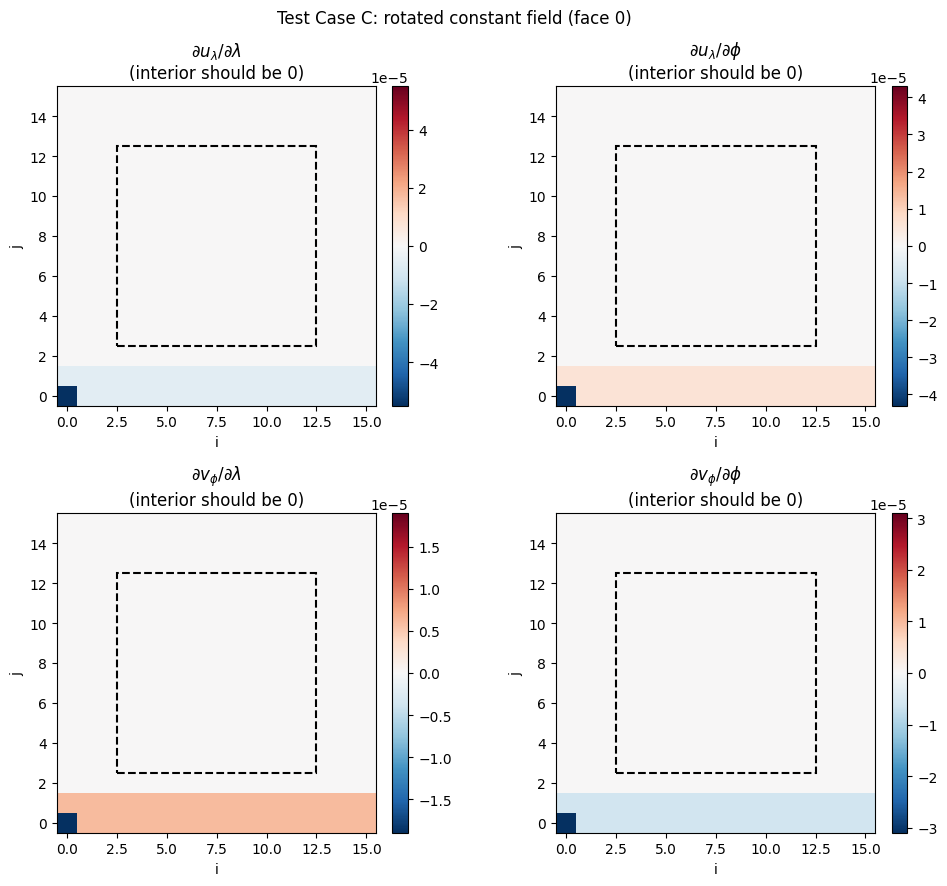

In [3]:
m = tj.EDGE_MARGIN
n = ds.sizes['i']
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (lab, o) in zip(axes.ravel(), zip(labels, outs)):
    img = o.isel(face=FACE).values
    vmax = np.nanmax(np.abs(img)) or 1.0
    pcm = ax.imshow(img, origin='lower', cmap='RdBu_r',
                    vmin=-vmax, vmax=vmax)
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.add_patch(Rectangle((m - 0.5, m - 0.5), n - 2 * m, n - 2 * m,
                           fill=False, ec='k', ls='--', lw=1.5))
    ax.set_title(f'{lab}\n(interior should be 0)')
    ax.set_xlabel('i'); ax.set_ylabel('j')
fig.suptitle('Test Case C: rotated constant field (face %d)' % FACE)
fig.tight_layout(); plt.show()


## 3. Interior vs. edge magnitudes

A line cut across a row makes the contrast plain: flat zero in the
interior, spikes only in the trimmed margins.

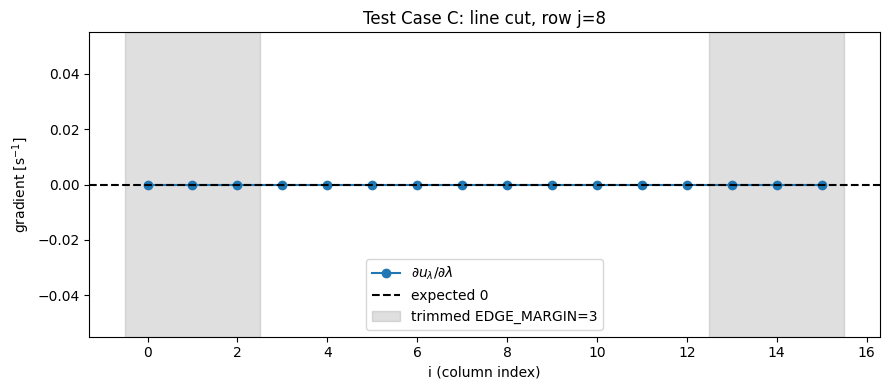

global interior max |grad| over all components = 0.0


In [4]:
row = n // 2
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(n), dudl.isel(face=FACE, j=row).values, 'o-',
        label=labels[0])
ax.axhline(0.0, color='k', ls='--', label='expected 0')
ax.axvspan(-0.5, m - 0.5, color='grey', alpha=0.25)
ax.axvspan(n - m - 0.5, n - 0.5, color='grey', alpha=0.25,
           label=f'trimmed EDGE_MARGIN={m}')
ax.set_xlabel('i (column index)')
ax.set_ylabel('gradient [s$^{-1}$]')
ax.set_title('Test Case C: line cut, row j=%d' % row)
ax.legend(); fig.tight_layout(); plt.show()

print('global interior max |grad| over all components =',
      max(float(np.abs(tj.interior(o).values).max()) for o in outs))


## 4. Run the actual unit test

No exception means Test Case C passes.

In [5]:
tj.test_jacobian_rotation_only_constant_field_zero_gradient()
print('Test Case C passed.')


Test Case C passed.
